# Traning Model - SAMPLE version

In this notebook, we will train a model to predict fraud. We will use the following models:
- K-Nearest Neighbors
- Random Forest
- LightGBM  
- XGBoost


In [12]:
## import libraries
import pandas as pd
import numpy as np 
import imblearn
from matplotlib.pyplot import figure
from sklearn.utils import shuffle
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix, precision_score, recall_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.under_sampling import RandomUnderSampler
from sklearn import metrics
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier

In [13]:
## function to evaluate model
list_of_models = []
def evaluate_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, fbeta, support = precision_recall_fscore_support(y_true, y_pred, beta=5, pos_label=1, average='binary')
    auc = roc_auc_score(y_true, y_pred)
    String = f"Model: {name}\n Accuracy: {accuracy:.4f}\n Precision: {precision:.4f}\n Recall: {recall:.4f}\n Fscore: {fbeta:.4f}\n AUC: {auc:.4f}"
    list_of_models.append(String)
    print(String)

In [14]:
df = pd.read_csv('../data/card_transdata.csv')


In [15]:
rs=123
def split_data(df):
    X = df.loc[ : , df.columns != 'fraud']
    y = df['fraud'].astype('int')
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state = rs)

In [16]:
X_train, X_test, y_train, y_test = split_data(df)

In [17]:
## Example of using SMOTE to oversample the minority class
from imblearn.over_sampling import SMOTE, RandomOverSampler
smote = SMOTE(random_state=rs)

X_smo, y_smo = smote.fit_resample(X_train, y_train)

<Axes: xlabel='fraud'>

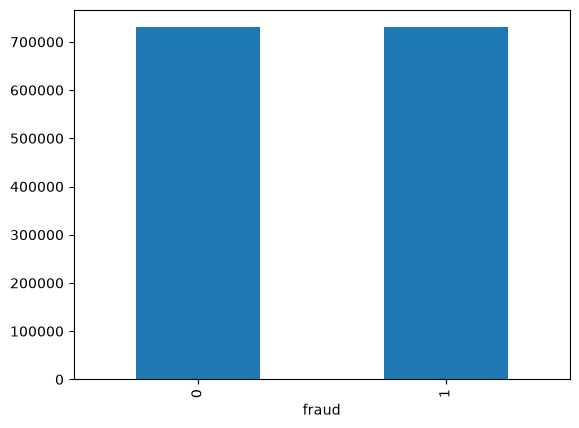

In [18]:

y_smo.value_counts().plot.bar("green", "red")

### KNN With SMOTE and QuantileTransformer
This model was more than anything a test although it had a very good metrics. 

In [19]:
continuous_cols = ["distance_from_home", "distance_from_last_transaction", "ratio_to_median_purchase_price"]
pr = ColumnTransformer(
    transformers=[
        ('quantile', QuantileTransformer(output_distribution='normal'), continuous_cols)
    ],
    remainder='passthrough'
)

In [20]:
pipeline_knn = Pipeline(steps=[
    ('preprocessor', pr),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

In [21]:
pipeline_knn.fit(X_smo, y_smo)
preds_smo = pipeline_knn.predict(X_test)



In [22]:
evaluate_model("KNN with Pipeline and SMOTE", y_test, preds_smo)

Model: KNN with Pipeline and SMOTE
 Accuracy: 0.9936
 Precision: 0.9430
 Recall: 0.9864
 Fscore: 0.9847
 AUC: 0.9904


### Random Forest with SMOTE
This model was the best model in terms of metrics. The model was trained using SMOTE to oversample the minority class and Random Forest as the classifier. but even if has perfect metrics, this is not good means that the model has overfitted the data and it is not generalizable to new data.

In [23]:
rf = RandomForestClassifier(n_estimators=100, random_state=rs, n_jobs=-1)

In [25]:
rf.fit(X_smo, y_smo)
preds_rf_smo = rf.predict(X_test)


In [26]:
evaluate_model("Random Forest with SMOTE", y_test, preds_rf_smo)

Model: Random Forest with SMOTE
 Accuracy: 1.0000
 Precision: 1.0000
 Recall: 1.0000
 Fscore: 1.0000
 AUC: 1.0000


### XGBoost with SMOTE
This model got some good metrics and more than those of Random Forest. But classified it as the second best model

In [27]:
import xgboost as xgb

In [28]:
ratio_balance = (y_train == 0).sum() / (y_train == 1).sum()

In [29]:
xg_model = xgb.XGBClassifier(scale_pos_weight=ratio_balance, random_state=rs, n_jobs=-1)

In [30]:
xg_model.fit(X_smo, y_smo)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
predictions_xg = xg_model.predict(X_test)

In [32]:
evaluate_model("XGBoost with SMOTE", y_test, predictions_xg)

Model: XGBoost with SMOTE
 Accuracy: 0.9980
 Precision: 0.9785
 Recall: 0.9994
 Fscore: 0.9986
 AUC: 0.9987


## LightGBM with SMOTE
This model got some good metrics and more than those of Random Forest. it was the best model, it's not in overfitting and it doesn't have perfect metrics.

In [33]:
import lightgbm as lgb
l_gbm = lgb.LGBMClassifier(is_unbalanced=True,random_state=rs, n_jobs=-1)

In [34]:
l_gbm.fit(X_smo, y_smo)

[LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Info] Number of positive: 730078, number of negative: 730078
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024468 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 1460156, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,random_state,123
,n_jobs,-1
,is_unbalanced,True
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [35]:
pred_smo_gbm = l_gbm.predict(X_test)

[LightGBM] [Warning] Unknown parameter: is_unbalanced


In [36]:
evaluate_model("LightGBM with SMOTE", y_test, pred_smo_gbm)


Model: LightGBM with SMOTE
 Accuracy: 0.9985
 Precision: 0.9837
 Recall: 0.9994
 Fscore: 0.9988
 AUC: 0.9989


In [37]:
for model in list_of_models:
    print(model)

Model: KNN with Pipeline and SMOTE
 Accuracy: 0.9936
 Precision: 0.9430
 Recall: 0.9864
 Fscore: 0.9847
 AUC: 0.9904
Model: Random Forest with SMOTE
 Accuracy: 1.0000
 Precision: 1.0000
 Recall: 1.0000
 Fscore: 1.0000
 AUC: 1.0000
Model: XGBoost with SMOTE
 Accuracy: 0.9980
 Precision: 0.9785
 Recall: 0.9994
 Fscore: 0.9986
 AUC: 0.9987
Model: LightGBM with SMOTE
 Accuracy: 0.9985
 Precision: 0.9837
 Recall: 0.9994
 Fscore: 0.9988
 AUC: 0.9989


#### Conclusion:
LightGBM is the optimal model for this fraud detection pipeline, delivering the best balance between predictive power, operational efficiency, and real-time viability